In [1]:
import torch

from BirdDataset import *

from BCommon import *

In [2]:
location = "data/soundscape_recordings_amazon/"

data_folder = "recordings/"
annotations = "annotations_divided_overfit.csv"

train_dataset = BirdDataset(data_path = location + data_folder, annotations_file = location + annotations, split="train")
val_dataset   = BirdDataset(data_path = location + data_folder, annotations_file = location + annotations, split="val")

print(len(train_dataset), len(val_dataset))

280 280


torch.Size([1, 128, 126]) amabaw1


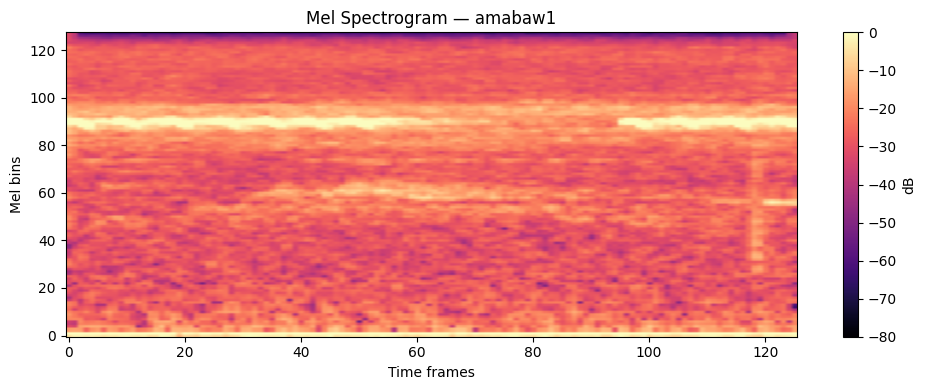

In [3]:
mel, label = train_dataset[5]
print(mel.shape, label)

mel_db = mel.cpu().numpy().squeeze(0)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.imshow(mel_db, aspect='auto', origin='lower', cmap='magma', vmin=-80, vmax=0)
plt.title(f"Mel Spectrogram — {label}")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

In [4]:
import json

with open(location + "label_encodings.json", "r") as f:
    encodings = json.load(f)

label_to_idx = encodings["label_to_idx"]
idx_to_label = {int(k): v for k, v in encodings["idx_to_label"].items()}

In [ ]:
precompute_mels(
    annotations_file=location + annotations,
    recordings_dir=location + data_folder,
    output_dir=location + data_folder + annotations + ".precomputed/",
)

precompute_mels(
    annotations_file=location + annotations,
    recordings_dir=location + "recordings_clean/",
    output_dir=location + "recordings_clean/" + annotations + ".precomputed/",
)

🧠 Using 15 CPU workers


Precomputing mels:   0%|          | 0/560 [00:00<?, ?it/s]

In [5]:
from torch.utils.data import ConcatDataset

train_dataset = BirdDataset(
    data_path = location + data_folder,
    annotations_file = location + annotations, 
    split="train", 
    label_to_idx=label_to_idx, 
    encode_labels=True,
    pad="auto",
    precomputed=True,
    precomputed_dir=location + data_folder + annotations + ".precomputed",
    )
train_clean_dataset = BirdDataset(
    data_path = location + "recordings_clean/", 
    annotations_file = location + annotations, 
    split="train", 
    label_to_idx=label_to_idx, 
    encode_labels=True,
    pad="auto",
    precomputed=True,
    precomputed_dir=location + "recordings_clean/" + annotations + ".precomputed/",
    )
train_dataset = ConcatDataset([train_dataset, train_clean_dataset])

val_dataset = BirdDataset(
    data_path = location + data_folder, 
    annotations_file = location + annotations, 
    split="val", 
    label_to_idx=label_to_idx, 
    encode_labels=True,
    pad="auto",
    precomputed=True,
    precomputed_dir=location + data_folder + annotations + ".precomputed",
    )

In [6]:
batch_size = 32

In [7]:
trainloader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True, 
    num_workers=os.cpu_count() // 2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)

valloader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=batch_size,
    shuffle=True, 
    num_workers=os.cpu_count() // 2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)

In [8]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4070


In [9]:
from models.BirdModels import BirdCNN

model = BirdCNN(n_mels=128, n_classes=len(label_to_idx)).to("cuda")

In [ ]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, momentum=0.9)

In [ ]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
num_epochs = 100
best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n🟢 Epoch {epoch+1}/{num_epochs}")
    print("-" * 50)

    # ---------- TRAIN ----------
    model.train()
    running_loss = 0.0
    train_bar = tqdm(trainloader, desc="Training", leave=False)
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = running_loss / len(trainloader)
    print(f"✅ Average training loss: {avg_train_loss:.4f}")

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        val_bar = tqdm(valloader, desc="Validating", leave=False)
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy (for classification)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(valloader)
    val_acc = 100 * correct / total
    print(f"📉 Validation loss: {avg_val_loss:.4f} | 🎯 Accuracy: {val_acc:.2f}%")

    # ---------- SAVE BEST MODEL ----------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("💾 Saved new best model!")

print("\n🏁 Training completed.")


In [14]:
import torch, time
model.train()
batch_inputs, batch_labels = next(iter(trainloader))           # grab ONE batch
batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.long().to(device)

losses = []
t0 = time.time()
for step in range(500):  # should drop sharply
    optimizer.zero_grad(set_to_none=True)
    logits = model(batch_inputs)
    loss = criterion(logits, batch_labels)
    loss.backward()
    optimizer.step()
    if (step+1) % 50 == 0:
        with torch.no_grad():
            preds = logits.argmax(1)
            acc = (preds == batch_labels).float().mean().item()*100
        print(f"step {step+1:3d} | loss {loss.item():.4f} | acc {acc:.1f}%")
print("done in", round(time.time()-t0,2), "s")

step  50 | loss 1.2105 | acc 65.6%
step 100 | loss 0.9689 | acc 78.1%
step 150 | loss 0.8354 | acc 87.5%
step 200 | loss 0.6606 | acc 93.8%
step 250 | loss 0.5983 | acc 93.8%
step 300 | loss 0.4687 | acc 96.9%
step 350 | loss 0.4460 | acc 96.9%
step 400 | loss 0.4306 | acc 96.9%
step 450 | loss 0.3754 | acc 100.0%
step 500 | loss 0.3445 | acc 100.0%
done in 24.2 s
